In [2]:
# import libraries

import pandas as pd
import numpy as np

import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,

    TrainingArguments,
    Trainer
)

d:\2025\Workspace\Vietnamese-Sentiment-Analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# check if GPU is available
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [4]:
# load the dataset

train_df = pd.read_csv("../dataset/synthetic_train.csv")
val_df = pd.read_csv("../dataset/synthetic_val.csv")

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

In [5]:
from pyvi import ViTokenizer

train_df["sentence"] = train_df["sentence"].apply(
    ViTokenizer.tokenize
)

val_df["sentence"] = val_df["sentence"].apply(
    ViTokenizer.tokenize
)

d:\2025\Workspace\Vietnamese-Sentiment-Analysis\venv\Lib\site-packages\pyvi\ViTokenizer.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  model = pickle.load(fin)


In [6]:
label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

In [7]:
train_df['label'] = train_df['sentiment'].map(label2id)
val_df['label'] = val_df['sentiment'].map(label2id)

train_df[['sentiment', 'label']].head()

,sentiment,label
0,negative,0
1,neutral,1
2,neutral,1
3,positive,2
4,neutral,1


In [8]:
# convert the dataframes to Hugging Face datasets

train_dataset = Dataset.from_pandas(
    train_df[['sentence', 'label']]
)

val_dataset = Dataset.from_pandas(
    val_df[['sentence', 'label']]
)

In [9]:
# load PhoBERT tokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "vinai/phobert-base",
    use_fast=False
)

In [10]:
tokenizer(
    "Giảng viên rất nhiệt tình"
)

{'input_ids': [0, 34199, 1430, 59, 2515, 939, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}

In [41]:
def tokenize(batch):
    return tokenizer(
        batch['sentence'],
        padding='max_length',
        truncation=True,
        max_length=48
    )

In [43]:
train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize,
    batched=True
)

Map: 100%|██████████| 2036/2036 [00:00<00:00, 8445.09 examples/s]


In [44]:
model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/phobert-base",
    num_labels=3,
    id2label={0: "negative", 1: "neutral", 2: "positive"},
    label2id={"negative": 0, "neutral": 1, "positive": 2},
    use_safetensors=True
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5472.87it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your

In [45]:
print(model.config.id2label)

{0: 'negative', 1: 'neutral', 2: 'positive'}


In [46]:
training_args = TrainingArguments(
    output_dir="../results",

    eval_strategy="epoch",
    save_strategy="epoch",
    
    learning_rate=2e-5,
    num_train_epochs=3,
    
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    gradient_accumulation_steps=4,
    
    fp16=True,

    weight_decay=0.01,
    
    logging_steps=50,
    load_best_model_at_end=True,

    report_to="none",
    
)

In [47]:
from sklearn.metrics import accuracy_score, f1_score

In [48]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy':
        accuracy_score(labels, preds),
        'f1':
        f1_score(
            labels,
            preds,
            average='weighted'
        )
    }

In [49]:
import torch
from torch.nn import CrossEntropyLoss

weights = torch.tensor([1.0, 1.0, 1.5]).to("cuda")
loss_fct = CrossEntropyLoss(weight=weights)

In [50]:
from transformers import Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [51]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

In [40]:
train_df["sentence"].str.split().apply(len).describe()

count    8144.000000
mean       12.551449
std         3.849790
min         2.000000
25%        10.000000
50%        12.000000
75%        15.000000
max        33.000000
Name: sentence, dtype: float64

In [52]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.296314,0.328949,0.854617,0.854106
2,1.044255,0.328151,0.858546,0.857571
3,0.890629,0.304136,0.880157,0.880017


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.22it/s]


TrainOutput(global_step=1527, training_loss=1.3354120123362963, metrics={'train_runtime': 602.9821, 'train_samples_per_second': 40.519, 'train_steps_per_second': 2.532, 'total_flos': 602661283305984.0, 'train_loss': 1.3354120123362963, 'epoch': 3.0})

In [53]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.890629,0.304136,3,0.880157,0.880017


{'eval_loss': 0.3041364848613739,
 'eval_accuracy': 0.8801571709233792,
 'eval_f1': 0.8800170065198131}

In [54]:
predictions = trainer.predict(val_dataset)

In [55]:
y_pred = predictions.predictions.argmax(axis=1)

y_true = predictions.label_ids

In [56]:
# classification report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            'negative',
            'neutral',
            'positive'
        ]
    )
)

              precision    recall  f1-score   support

    negative       0.98      0.98      0.98       686
     neutral       0.83      0.80      0.82       670
    positive       0.83      0.86      0.84       680

    accuracy                           0.88      2036
   macro avg       0.88      0.88      0.88      2036
weighted avg       0.88      0.88      0.88      2036



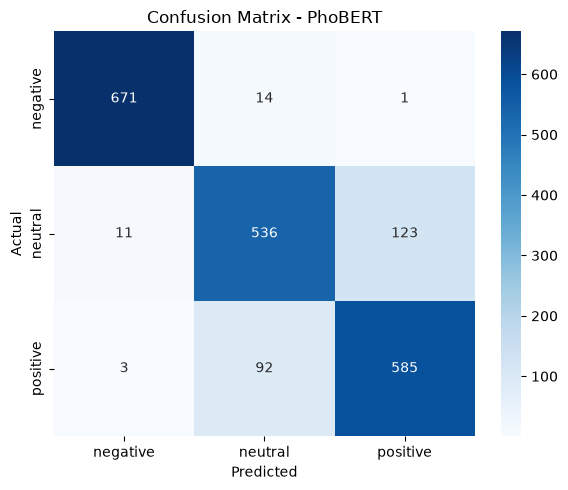

In [57]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'negative',
        'neutral',
        'positive'
    ],
    yticklabels=[
        'negative',
        'neutral',
        'positive'
    ]
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - PhoBERT')
plt.tight_layout()

plt.savefig('../images/confusion_matrix_phobert.png', dpi=300)

plt.show()

In [61]:
import os

# Tạo đường dẫn thư mục con bên trong thư mục models hiện tại của bạn
save_path = "../models/phobert_sentiment"

# Nếu thư mục chưa tồn tại thì tự động tạo mới
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Lưu model và cấu hình
trainer.save_model(save_path)

# Lưu tokenizer (cực kỳ quan trọng để sau này xử lý text đầu vào)
tokenizer.save_pretrained(save_path)

print(f"Đã lưu thành công toàn bộ model và tokenizer vào: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.05it/s]

Đã lưu thành công toàn bộ model và tokenizer vào: ../models/phobert_sentiment
